In [3]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import msaf

sns.set(style="darkgrid")

In [4]:
def extract_features(filepath):
    y, sr = librosa.load(filepath, sr=None)
    
    features = {}
    
    features["duration"] = librosa.get_duration(y=y, sr=sr)
    
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    features["tempo"] = float(np.mean(tempo))
    
    features["rms_mean"] = np.mean(librosa.feature.rms(y=y))
    features["spectral_centroid_mean"] = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    features["spectral_bandwidth_mean"] = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    features["spectral_rolloff_mean"] = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    features["zcr_mean"] = np.mean(librosa.feature.zero_crossing_rate(y))
    
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    features["chroma_mean"] = np.mean(chroma)
    features["chroma_std"] = np.std(chroma)
    
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(13):
        features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
        features[f"mfcc_{i+1}_std"] = np.std(mfcc[i])
    
    return features

In [5]:
def structural_features(filepath):
    boundaries, labels = msaf.process(filepath, boundaries_id="foote")
    
    segment_lengths = np.diff(boundaries)
    labels_array = np.array(labels)
    non_negative_labels = labels_array[labels_array != -1]
    unique_labels = set(labels_array)
    
    entropy = 0
    for l in unique_labels:
        if l != -1:
            p = list(labels_array).count(l) / len(labels_array)
            entropy += -p * np.log2(p)
    
    return {
        "num_segments": len(segment_lengths),
        "avg_segment_length": np.mean(segment_lengths),
        "segment_length_std": np.std(segment_lengths),
        "num_structured_sections": len(non_negative_labels),
        "structure_ratio": len(non_negative_labels) / len(labels_array),
        "unique_sections": len(unique_labels) - (1 if -1 in unique_labels else 0),
        "label_entropy": entropy
    }

In [6]:
base_folder = "song_mp3"
rows = []

for decade_folder in os.listdir(base_folder):
    decade_path = os.path.join(base_folder, decade_folder)
    
    if os.path.isdir(decade_path):
        for file in os.listdir(decade_path):
            if file.endswith(".mp3"):
                filepath = os.path.join(decade_path, file)
                
                audio_feats = extract_features(filepath)
                struct_feats = structural_features(filepath)
                
                combined = {**audio_feats, **struct_feats}
                combined["song"] = file
                combined["decade"] = decade_folder
                
                rows.append(combined)

df_all = pd.DataFrame(rows)

df_all.head()

,duration,tempo,rms_mean,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,zcr_mean,chroma_mean,chroma_std,mfcc_1_mean,...,mfcc_13_std,num_segments,avg_segment_length,segment_length_std,num_structured_sections,structure_ratio,unique_sections,label_entropy,song,decade
0,207.818594,126.048018,0.068001,3944.613535,3428.667403,7581.554409,0.116745,0.450424,0.287771,-176.661972,...,7.272492,10,20.781859,8.745345,1,0.100000,1,0.332193,John Mellencamp - Hurts So Good (Official Musi...,1980
1,222.772245,109.956782,0.073997,2207.330012,2290.178065,4249.309271,0.056084,0.533366,0.301138,-285.016327,...,8.708879,10,22.277224,10.099331,1,0.100000,1,0.332193,Queen - Another One Bites the Dust (Official V...,1980
2,195.210159,132.512019,0.041501,2968.554367,3052.155296,5999.248996,0.078461,0.462225,0.286070,-265.371918,...,7.057568,12,16.267513,9.861077,2,0.166667,1,0.430827,Rick Springfield - Jessie's Girl (Official Vid...,1980
3,233.418604,130.813953,0.122978,3121.716314,3187.509032,6383.348732,0.073127,0.451756,0.289598,-154.226959,...,8.188738,14,16.672760,9.987449,2,0.142857,1,0.401051,Laura Branigan - Gloria (1982) Good Audio Qual...,1980
4,182.546667,175.781250,0.135880,3161.733494,3741.900238,6986.093713,0.058150,0.522094,0.284306,-202.815826,...,9.805795,16,11.409167,6.416866,2,0.125000,1,0.375000,Red Red Wine (Remastered).mp3,1980


In [7]:
df_decade = df_all.groupby("decade").mean(numeric_only=True).reset_index()

df_decade

,decade,duration,tempo,rms_mean,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,zcr_mean,chroma_mean,chroma_std,...,mfcc_12_std,mfcc_13_mean,mfcc_13_std,num_segments,avg_segment_length,segment_length_std,num_structured_sections,structure_ratio,unique_sections,label_entropy
0,1950,157.398497,115.764328,0.139713,2178.061222,2658.125049,4336.708496,0.047033,0.405836,0.303802,...,8.372053,1.540173,7.939482,8.8,19.163900,11.604647,1.6,0.206190,1.0,0.438857
1,1960,150.140227,123.117747,0.133542,2459.997970,2552.330898,4816.570057,0.066433,0.430325,0.293123,...,7.971499,3.423395,7.200321,10.0,17.704533,11.401505,1.4,0.156294,1.0,0.398696
2,1970,231.906541,123.867706,0.141568,2570.406218,3213.799951,5398.031930,0.052342,0.447394,0.289250,...,9.351866,-2.225338,8.471669,12.0,19.883802,11.207363,1.6,0.145397,1.0,0.381966
3,1980,208.353254,135.022405,0.088472,3080.789545,3140.082007,6239.911024,0.076513,0.483973,0.289777,...,8.525957,2.076325,8.206694,12.4,17.481705,9.022013,1.6,0.126905,1.0,0.374253
4,1990,253.803392,126.232659,0.094677,2549.181309,2998.531750,5478.559270,0.054018,0.419874,0.308518,...,10.490192,-1.419080,9.092989,13.2,19.660250,9.628975,1.4,0.109643,1.0,0.337687
5,2000,216.937074,129.379984,0.154697,2776.502063,3245.476218,5982.792430,0.060911,0.430279,0.290104,...,9.117367,0.813570,8.042822,12.8,17.636493,9.820937,1.4,0.107889,1.0,0.343128
6,2010,241.533968,126.457648,0.224057,2812.105311,3143.559628,5920.492212,0.061011,0.468575,0.298227,...,9.686655,1.868724,8.683493,11.6,20.995691,10.459941,1.0,0.089103,1.0,0.308358


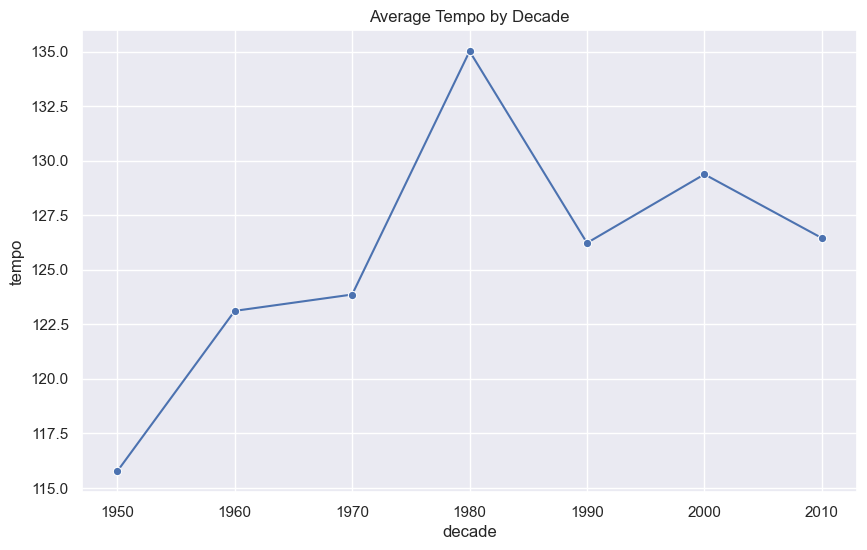

In [8]:
plt.figure(figsize=(10,6))
sns.lineplot(x="decade", y="tempo", data=df_decade, marker="o")
plt.title("Average Tempo by Decade")
plt.show()

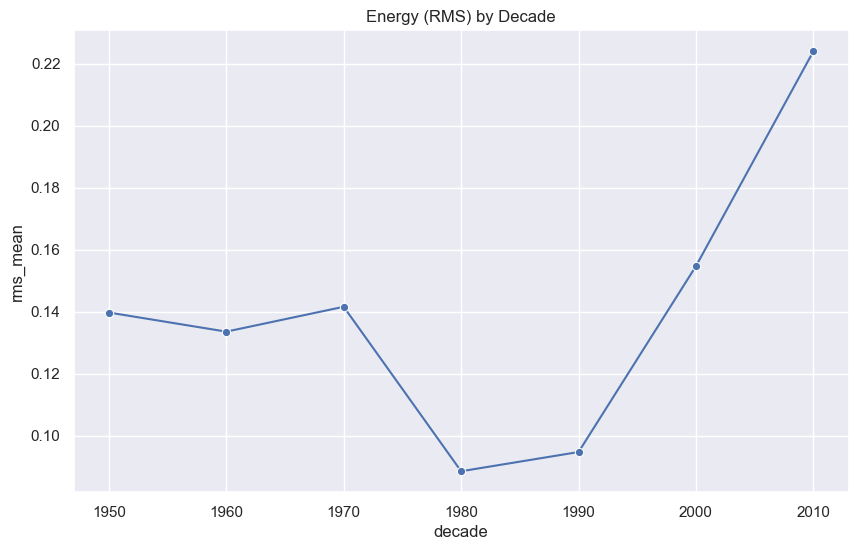

In [9]:
plt.figure(figsize=(10,6))
sns.lineplot(x="decade", y="rms_mean", data=df_decade, marker="o")
plt.title("Energy (RMS) by Decade")
plt.show()

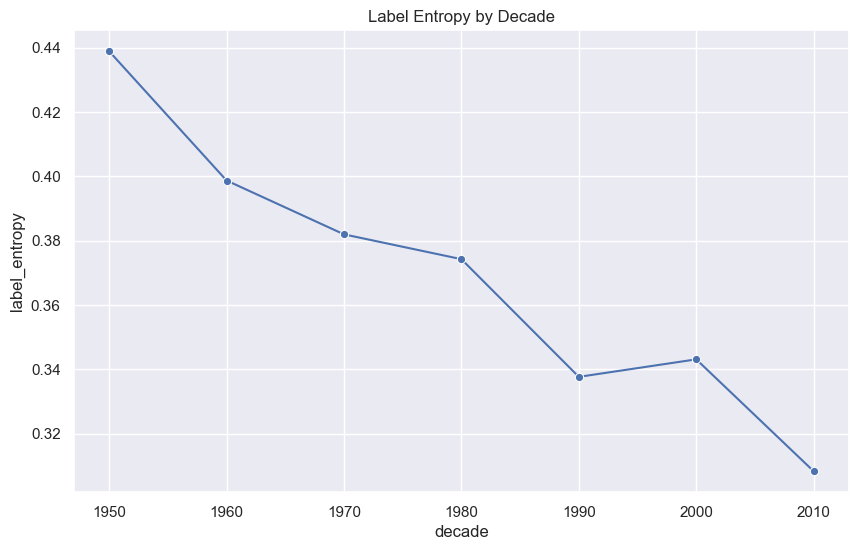

In [10]:
plt.figure(figsize=(10,6))
sns.lineplot(x="decade", y="label_entropy", data=df_decade, marker="o")
plt.title("Label Entropy by Decade")
plt.show()

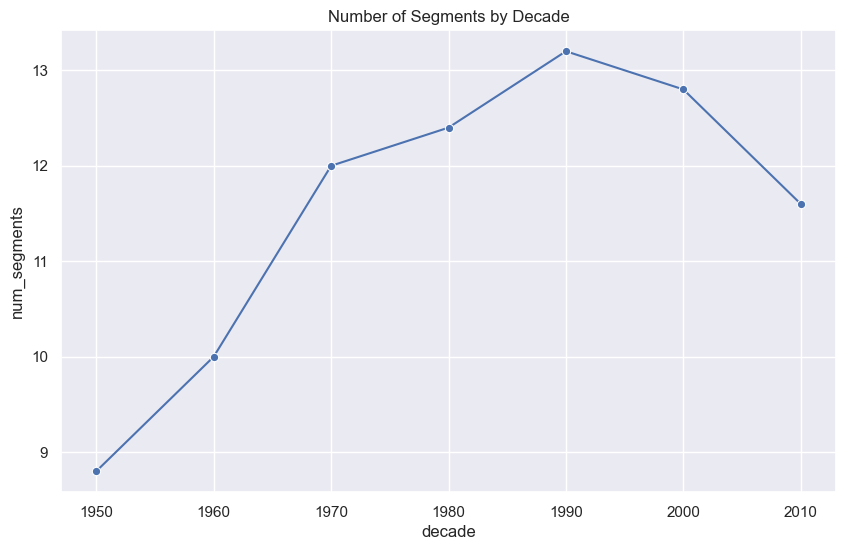

In [11]:
plt.figure(figsize=(10,6))
sns.lineplot(x="decade", y="num_segments", data=df_decade, marker="o")
plt.title("Number of Segments by Decade")
plt.show()

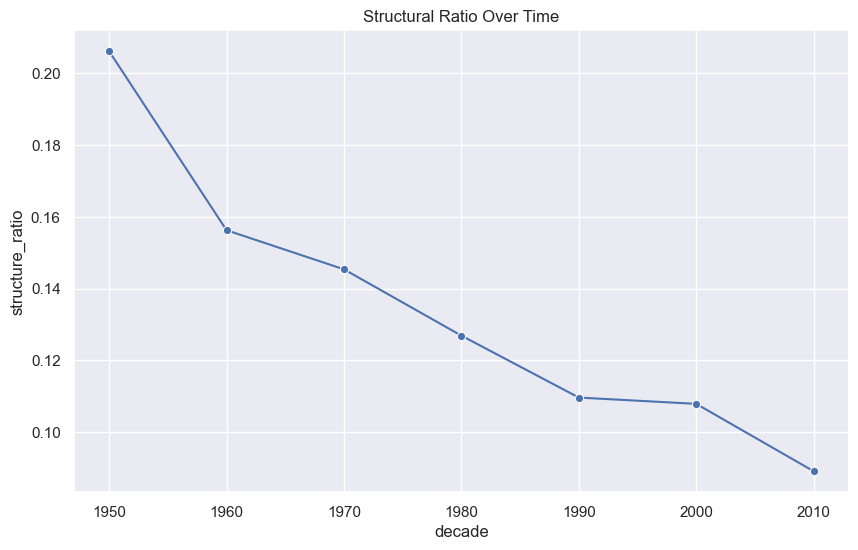

In [13]:
plt.figure(figsize=(10,6))
sns.lineplot(x="decade", y="structure_ratio", data=df_decade, marker="o")
plt.title("Structural Ratio Over Time")
plt.show()

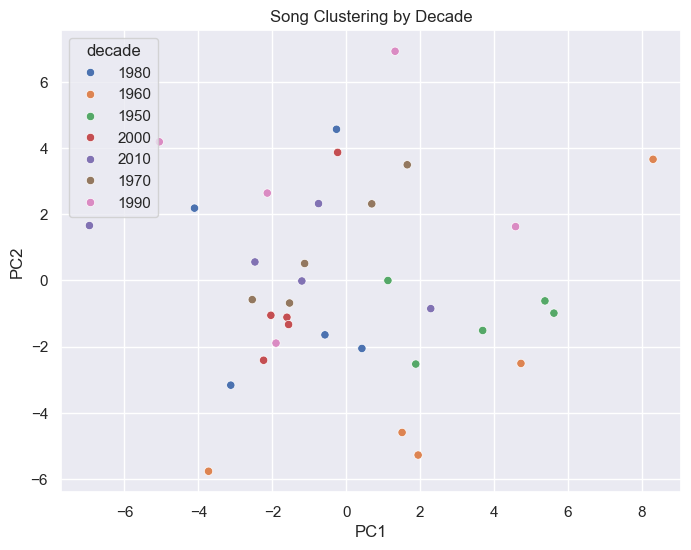

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features_for_pca = df_all.drop(columns=["song","decade"])
scaler = StandardScaler()
scaled = scaler.fit_transform(features_for_pca)

pca = PCA(n_components=2)
components = pca.fit_transform(scaled)

df_all["PC1"] = components[:,0]
df_all["PC2"] = components[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_all, x="PC1", y="PC2", hue="decade")
plt.title("Song Clustering by Decade")
plt.show()

In [15]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = np.arange(len(df_decade)).reshape(-1,1)
y = df_decade["label_entropy"].values

model = LinearRegression().fit(X,y)
print("Entropy trend slope:", model.coef_[0])

Entropy trend slope: -0.01953257189860309


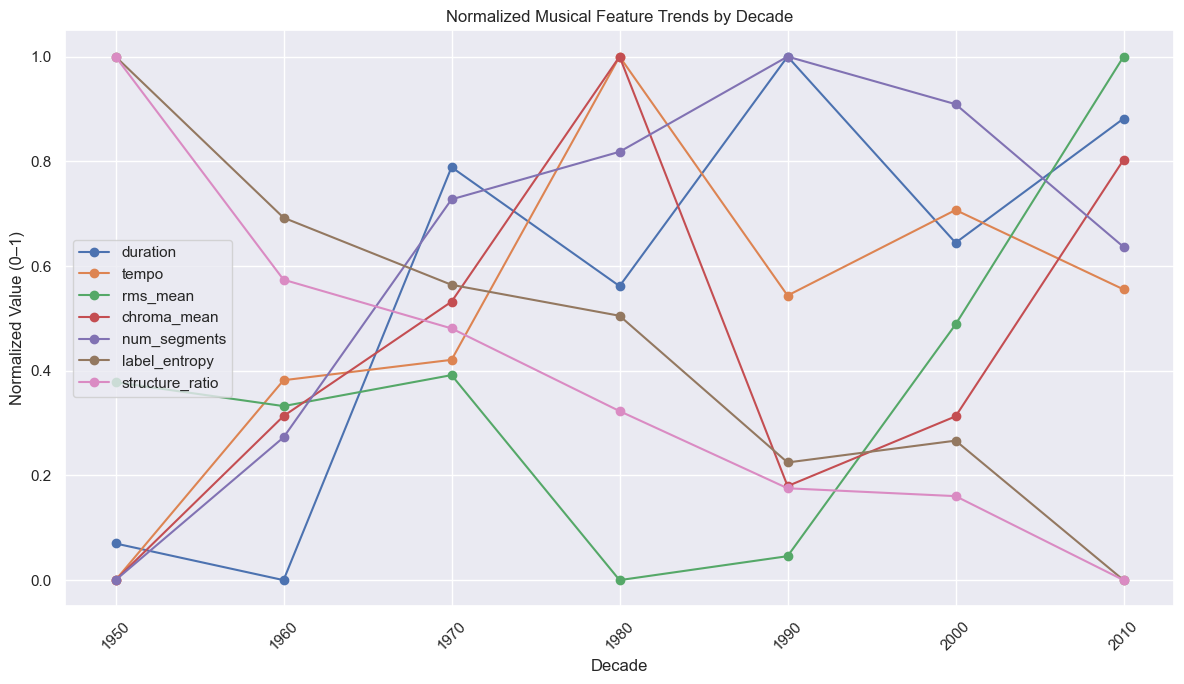

In [16]:
from sklearn.preprocessing import MinMaxScaler

features_to_plot = [
    "duration",
    "tempo",
    "rms_mean",
    "chroma_mean",
    "num_segments",
    "label_entropy",
    "structure_ratio"
]

# Normalize to 0–1 for fair comparison
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df_decade[features_to_plot])

scaled_df = pd.DataFrame(
    scaled_values,
    columns=features_to_plot
)

scaled_df["decade"] = df_decade["decade"]

# Plot
plt.figure(figsize=(12,7))

for feature in features_to_plot:
    plt.plot(
        scaled_df["decade"],
        scaled_df[feature],
        marker="o",
        label=feature
    )

plt.title("Normalized Musical Feature Trends by Decade")
plt.xlabel("Decade")
plt.ylabel("Normalized Value (0–1)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()